# Analyzing Vegetation & Precipitation in Central America

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

### Background & Literature:
In the paper *Assessing vegetation response to drought in the northern Great Plains using vegetation and drought indices* by Ji and Peters, they found that the 3 month SPI timescale had the strongest correlation with NDVI vegetation growth patterns when analyzing drought response in the northern Great Plains. Based on these findings I wanted to investigate whether similar vegetation responses to precipitation anomalies would occur across Central American countries and examine how vegetation reacts to different SPI timescales and lag periods in tropical climate regions.

### Research Question:
How does vegetation respond to precipitation anomalies at different timescales and time lags across Central American countries?

### Hypothesis: 
Vegetation indices will show stronger correlations with medium-term SPI (3–6 months), indicating delayed response to sustained moisture conditions.

### Data Acquistion:
**Source**: The dataset is from the Humanitarian Data Exchange platforms which is managed by the United Nations Office for the Coordination of Humanitarian Affairs (OCHA) Centre for Humanitarian Data.

In [2]:
url = 'https://raw.githubusercontent.com/sarayuvanam4a38-ctrl/Vegetation-and-Precipitation-in-Central-America/refs/heads/main/spi_crops.csv'
df = pd.read_csv(url)

### Data Inspection:

In [3]:
df.head()

,date,evi_avg,evi_category,ndvi_avg,ndvi_category,arvi_avg,arvi_category,sipi_avg,sipi_category,spi_1_avg,...,spi_3_category,spi_6_avg,spi_6_category,spi_9_avg,spi_9_category,spi_12_avg,spi_12_category,Country,Department,Municipality
0,2020-01-01 00:00:00+00:00,-0.85,3.Normal conditions,0.04,3.Normal conditions,-0.73,3.Normal conditions,-0.79,3.Normal conditions,0.45,...,Normal precipitation,0.02,Normal precipitation,-0.73,Normal precipitation,-0.70,Normal precipitation,El Salvador,Ahuachapan,Ahuachapan
1,2020-02-01 00:00:00+00:00,-0.35,3.Normal conditions,-0.13,3.Normal conditions,-0.36,3.Normal conditions,-0.17,3.Normal conditions,0.70,...,Normal precipitation,0.00,Normal precipitation,-0.84,Normal precipitation,-0.70,Normal precipitation,El Salvador,Ahuachapan,Ahuachapan
2,2020-03-01 00:00:00+00:00,0.77,3.Normal conditions,-0.59,3.Normal conditions,0.93,3.Normal conditions,1.19,2.Good conditions,0.38,...,Normal precipitation,0.18,Normal precipitation,-0.47,Normal precipitation,-0.68,Normal precipitation,El Salvador,Ahuachapan,Ahuachapan
3,2020-04-01 00:00:00+00:00,1.02,2.Good conditions,-0.75,3.Normal conditions,0.78,3.Normal conditions,1.16,2.Good conditions,-0.36,...,Normal precipitation,-0.41,Normal precipitation,-0.02,Normal precipitation,-0.74,Normal precipitation,El Salvador,Ahuachapan,Ahuachapan
4,2020-05-01 00:00:00+00:00,0.10,3.Normal conditions,0.08,3.Normal conditions,0.15,3.Normal conditions,-0.10,3.Normal conditions,0.44,...,Normal precipitation,0.35,Normal precipitation,0.19,Normal precipitation,-0.65,Normal precipitation,El Salvador,Ahuachapan,Ahuachapan


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78975 entries, 0 to 78974
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             78975 non-null  object 
 1   evi_avg          78933 non-null  float64
 2   evi_category     78933 non-null  object 
 3   ndvi_avg         78975 non-null  float64
 4   ndvi_category    78975 non-null  object 
 5   arvi_avg         78960 non-null  float64
 6   arvi_category    78960 non-null  object 
 7   sipi_avg         78972 non-null  float64
 8   sipi_category    78972 non-null  object 
 9   spi_1_avg        77852 non-null  float64
 10  spi_1_category   77852 non-null  object 
 11  spi_3_avg        77852 non-null  float64
 12  spi_3_category   77852 non-null  object 
 13  spi_6_avg        77852 non-null  float64
 14  spi_6_category   77852 non-null  object 
 15  spi_9_avg        77852 non-null  float64
 16  spi_9_category   77852 non-null  object 
 17  spi_12_avg  

### Cleaning the data:

In [5]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

df = df.rename(columns={
    'spi_1_avg': 'spi_1m_avg',
    'spi_3_avg': 'spi_3m_avg',
    'spi_6_avg': 'spi_6m_avg',
    'spi_9_avg': 'spi_9m_avg',
    'spi_12_avg': 'spi_12m_avg',
    'spi_1_category': 'spi_1m_category',
    'spi_3_category': 'spi_3m_category',
    'spi_6_category': 'spi_6m_category',
    'spi_9_category': 'spi_9m_category',
    'spi_12_category': 'spi_12m_category',
})

df = df.dropna()

### Figure 1:

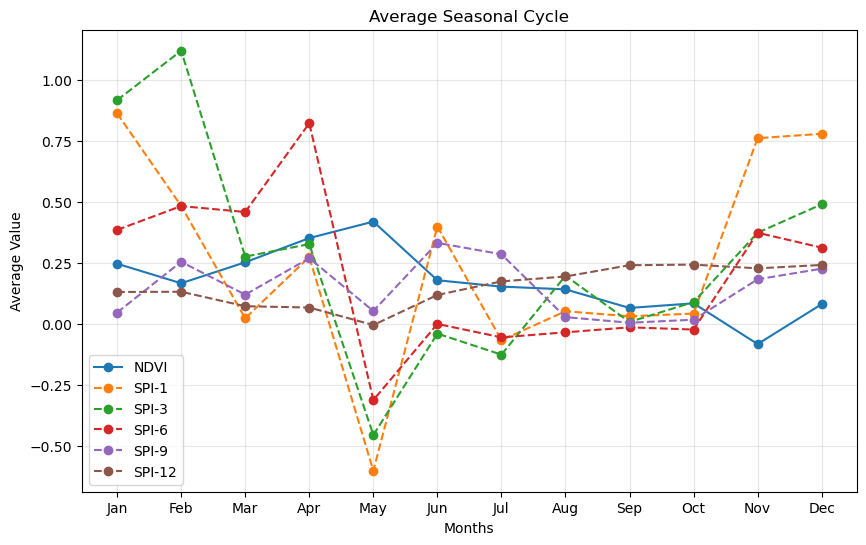

In [6]:
seasonal_cycle0 = df.groupby(df.index.month)['ndvi_avg'].mean()
seasonal_cycle4 = df.groupby(df.index.month)['spi_1m_avg'].mean()
seasonal_cycle5 = df.groupby(df.index.month)['spi_3m_avg'].mean()
seasonal_cycle6 = df.groupby(df.index.month)['spi_6m_avg'].mean()
seasonal_cycle7 = df.groupby(df.index.month)['spi_9m_avg'].mean()
seasonal_cycle8 = df.groupby(df.index.month)['spi_12m_avg'].mean()

seasonal_cycle0.plot(kind='line', marker='o', figsize=(10,6), label = 'NDVI')
seasonal_cycle4.plot(kind='line', linestyle= '--', marker='o', figsize=(10,6), label = 'SPI-1')
seasonal_cycle5.plot(kind='line', linestyle= '--', marker='o', figsize=(10,6), label = 'SPI-3')
seasonal_cycle6.plot(kind='line', linestyle= '--', marker='o', figsize=(10,6), label = 'SPI-6')
seasonal_cycle7.plot(kind='line', linestyle= '--', marker='o', figsize=(10,6), label = 'SPI-9')
seasonal_cycle8.plot(kind='line', linestyle= '--', marker='o', figsize=(10,6), label = 'SPI-12')

plt.title('Average Seasonal Cycle')
plt.xticks(np.arange(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Months')
plt.ylabel('Average Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Explanation:**

The seasonal cycle suggests that NDVI responds most to SPI-3 and SPI-6 because they closely align with the rises and declines in NDVI more. SPI-1 shows short-term variability, but its fluctuations are much sharper than the vegetation response, which shows that vegetation does not react immediately to short-term precipitation changes. SPI-9 and SPI-12 show a weaker apparent relationship with NDVI compared to SPI-3 and SPI-6 because they're much smoother and less variable over time which makes it more difficult to identify clear vegetation responses.

### Figure 2:

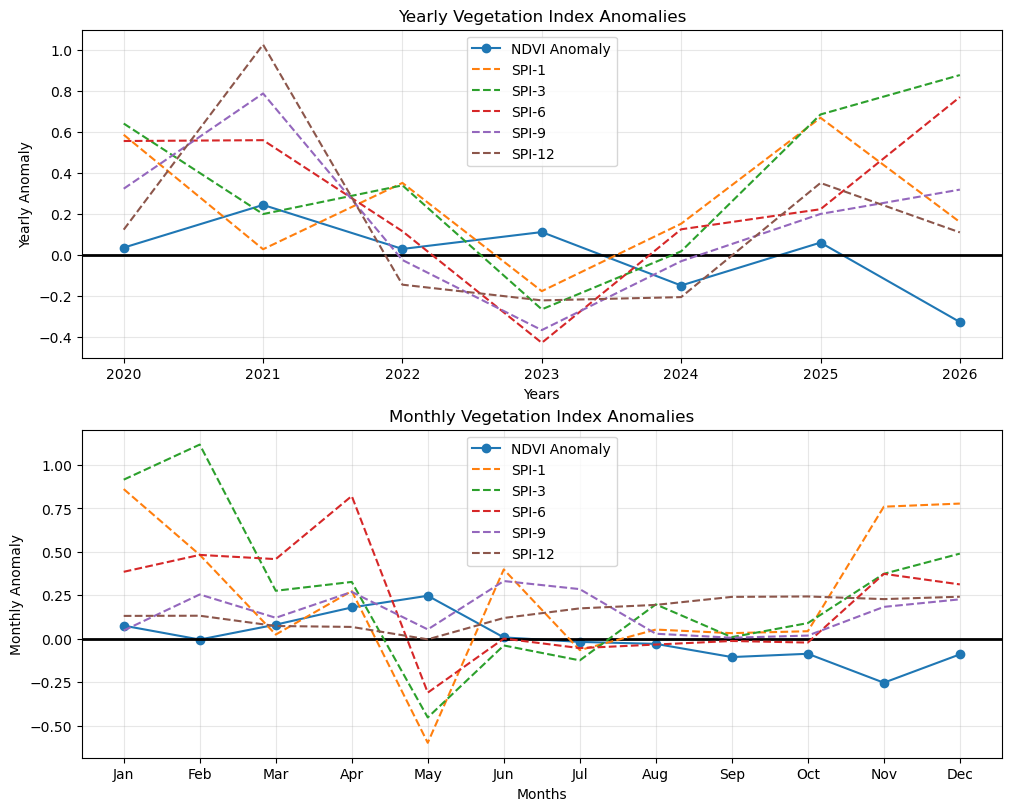

In [72]:
df['year'] = df.index.year
df_yearly = df.groupby('year')['ndvi_avg'].mean().reset_index()
df_yearly['ndvi_yearly_anomaly'] = df_yearly['ndvi_avg'] - df_yearly['ndvi_avg'].mean()

df['month'] = df.index.month
df_monthly = df.groupby('month')['ndvi_avg'].mean().reset_index()
df_monthly['ndvi_monthly_anomaly'] = df_monthly['ndvi_avg'] - df_monthly['ndvi_avg'].mean()

spi_1m_yearly_avg = df.groupby(df.index.year)['spi_1m_avg'].mean()
spi_3m_yearly_avg = df.groupby(df.index.year)['spi_3m_avg'].mean()
spi_6m_yearly_avg = df.groupby(df.index.year)['spi_6m_avg'].mean()
spi_9m_yearly_avg = df.groupby(df.index.year)['spi_9m_avg'].mean()
spi_12m_yearly_avg = df.groupby(df.index.year)['spi_12m_avg'].mean()

spi_1m_montly_avg = df.groupby(df.index.month)['spi_1m_avg'].mean()
spi_3m_montly_avg = df.groupby(df.index.month)['spi_3m_avg'].mean()
spi_6m_montly_avg = df.groupby(df.index.month)['spi_6m_avg'].mean()
spi_9m_montly_avg = df.groupby(df.index.month)['spi_9m_avg'].mean()
spi_12m_montly_avg = df.groupby(df.index.month)['spi_12m_avg'].mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 8), layout='constrained')

axes[0].plot(df_yearly['year'],df_yearly['ndvi_yearly_anomaly'],marker='o',label='NDVI Anomaly')
axes[0].axhline(0, color='black', linewidth=2)
axes[0].plot(spi_1m_yearly_avg, linestyle='--', label='SPI-1')
axes[0].plot(spi_3m_yearly_avg, linestyle='--', label='SPI-3')
axes[0].plot(spi_6m_yearly_avg, linestyle='--', label='SPI-6')
axes[0].plot(spi_9m_yearly_avg, linestyle='--', label='SPI-9')
axes[0].plot(spi_12m_yearly_avg, linestyle='--', label='SPI-12')
axes[0].set_xlabel('Years')
axes[0].set_title('Yearly Vegetation Index Anomalies')
axes[0].set_ylabel('Yearly Anomaly')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df_monthly['month'],df_monthly['ndvi_monthly_anomaly'],marker='o',label='NDVI Anomaly')
axes[1].axhline(0, color='black', linewidth=2)
axes[1].plot(spi_1m_montly_avg, linestyle='--', label='SPI-1')
axes[1].plot(spi_3m_montly_avg, linestyle='--', label='SPI-3')
axes[1].plot(spi_6m_montly_avg, linestyle='--', label='SPI-6')
axes[1].plot(spi_9m_montly_avg, linestyle='--', label='SPI-9')
axes[1].plot(spi_12m_montly_avg, linestyle='--', label='SPI-12')
axes[1].set_xticks(np.arange(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].set_xlabel('Months')
axes[1].set_title('Monthly Vegetation Index Anomalies')
axes[1].set_ylabel('Monthly Anomaly')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.show()

**Explanation:**

In the yearly anomaly figure the SPI timescales that coincide with the NDVI anamoly is SPI-6, SPI-9, SPI-12 because they match the fluctuations of the NDVI anamoly throughout the years. However in the monthly anomaly figure SPI-6 is the only one where the fluctuations match the growth pattern of the NDVI because SPI-9 and SPI-12 are much smoother and less variable over time which makes it more difficult to identify clear vegetation responses. Therefore SPI-6 is the most consistent SPI timescale which matches NDVI's growth pattern when looking at the monthly and yearly anomaly.

### Figure 3:

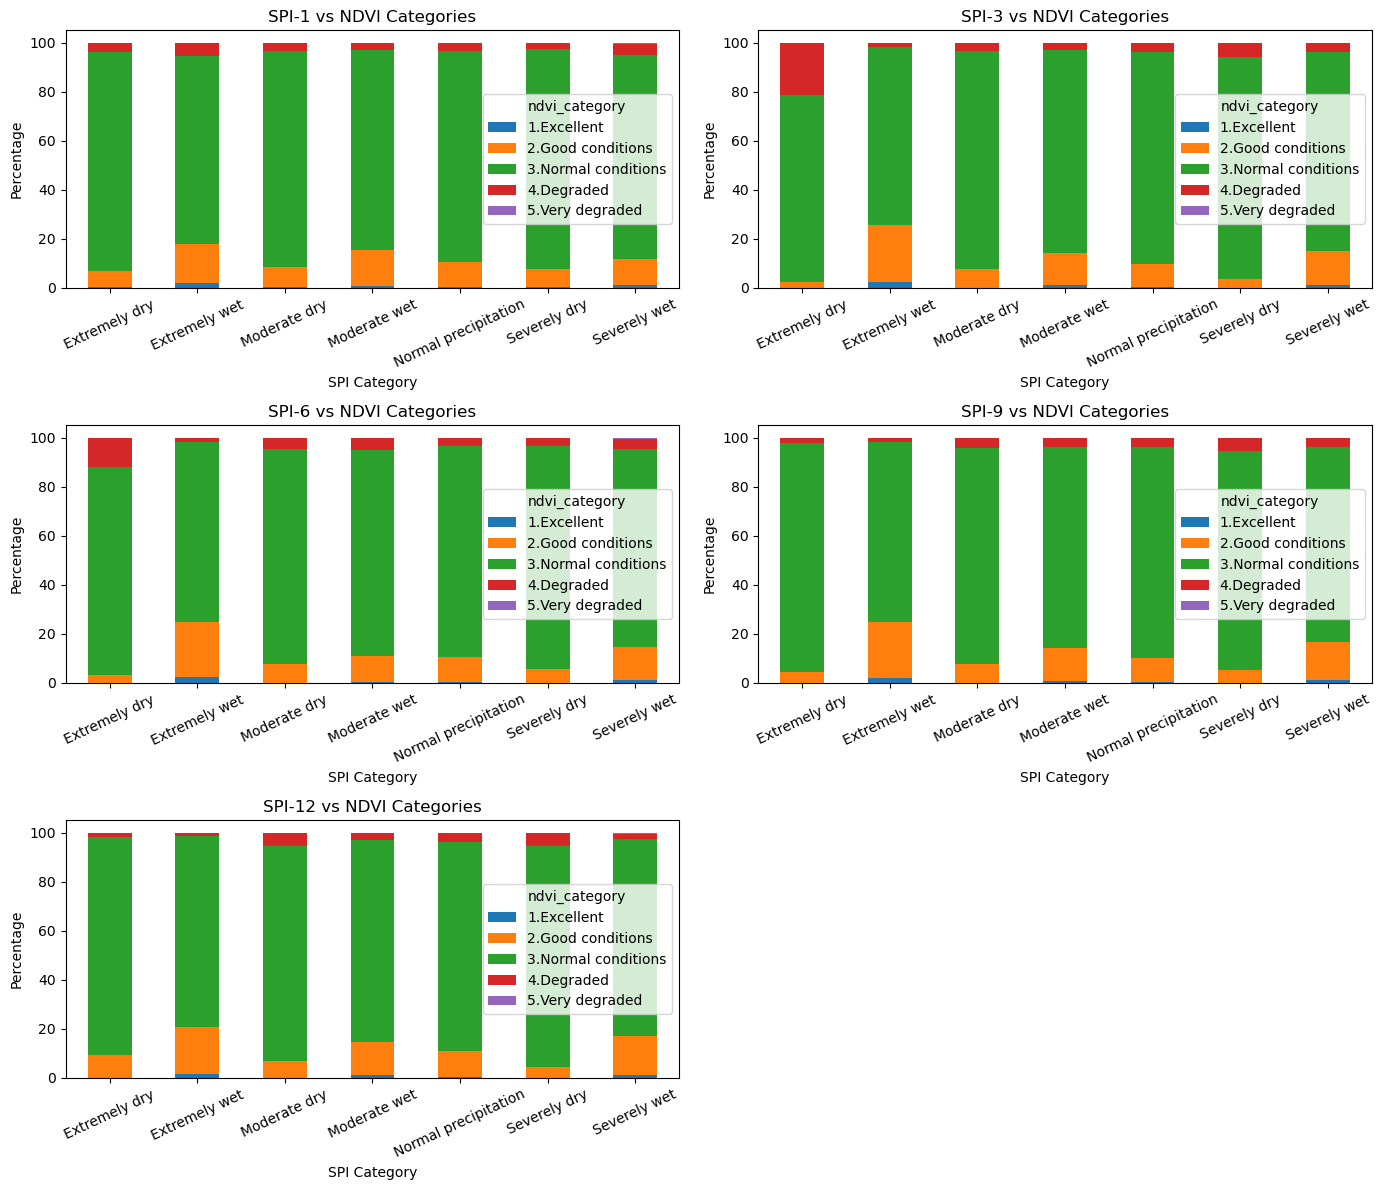

In [9]:
cts = [pd.crosstab(df['spi_1m_category'], df['ndvi_category'], normalize='index') * 100,
       pd.crosstab(df['spi_3m_category'], df['ndvi_category'], normalize='index') * 100,
       pd.crosstab(df['spi_6m_category'], df['ndvi_category'], normalize='index') * 100,
       pd.crosstab(df['spi_9m_category'], df['ndvi_category'], normalize='index') * 100,
       pd.crosstab(df['spi_12m_category'], df['ndvi_category'], normalize='index') * 100
      ]

titles = ['SPI-1 vs NDVI Categories', 'SPI-3 vs NDVI Categories', 'SPI-6 vs NDVI Categories', 'SPI-9 vs NDVI Categories',
          'SPI-12 vs NDVI Categories']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

i = 0
for ct in cts:
    ct.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('SPI Category')
    axes[i].set_ylabel('Percentage')
    axes[i].tick_params(axis='x', rotation=25)
    i += 1

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

**Explanation:**

The SPI-3 and SPI-6 timescales appear to show the strongest relationship with NDVI vegetation conditions compared to the other SPI timescales. These medium-term precipitation indices display slightly greater variation in vegetation categories across dry and wet precipitation conditions, suggesting that vegetation responds more noticeably to sustained seasonal moisture patterns rather than immediate short-term changes. However even if the conditions were dry or wet, vegetation usually stayed in normal condition, although medium-term precipitation anomalies (SPI-3 and SPI-6) caused slightly more changes in vegetation response.

### Figure 4:

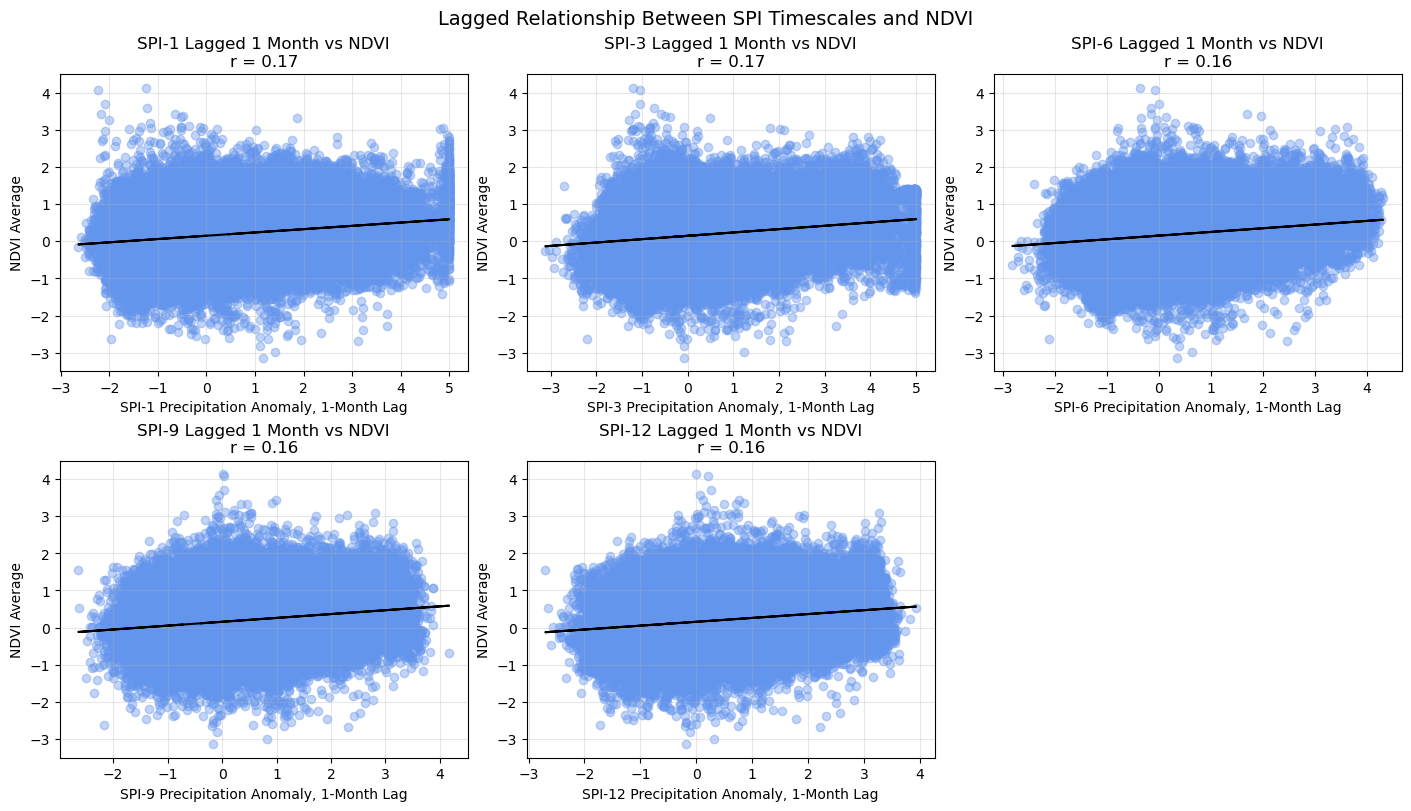

In [27]:
df['spi_1m_avg_lag1'] = df.groupby('Country')['spi_1m_avg'].shift(1)
df['spi_3m_avg_lag1'] = df.groupby('Country')['spi_3m_avg'].shift(1)
df['spi_6m_avg_lag1'] = df.groupby('Country')['spi_6m_avg'].shift(1)
df['spi_9m_avg_lag1'] = df.groupby('Country')['spi_9m_avg'].shift(1)
df['spi_12m_avg_lag1'] = df.groupby('Country')['spi_12m_avg'].shift(1)

spi_lag_cols = ['spi_1m_avg_lag1','spi_3m_avg_lag1','spi_6m_avg_lag1','spi_9m_avg_lag1','spi_12m_avg_lag1']
titles = ['SPI-1', 'SPI-3', 'SPI-6', 'SPI-9', 'SPI-12']

fig, axes = plt.subplots(2, 3, figsize=(14, 8), layout='constrained')

for ax, col, title in zip(axes.flat, spi_lag_cols, titles):
    sub = df.dropna(subset=[col, 'ndvi_avg'])
    if len(sub) > 1:
        r = sub[col].corr(sub['ndvi_avg'])
        m, b = np.polyfit(sub[f'{col}'], sub['ndvi_avg'], 1)
        ax.plot(sub[f'{col}'], m*sub[f'{col}'] + b, color = 'black')
    else:
        r = np.nan
    ax.scatter(sub[col], sub['ndvi_avg'], alpha=0.4, color= 'cornflowerblue')
    ax.set_title(f'{title} Lagged 1 Month vs NDVI\nr = {r:.2f}')
    ax.set_xlabel(f'{title} Precipitation Anomaly, 1-Month Lag')
    ax.set_ylabel('NDVI Average')
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[1, 2])
fig.suptitle('Lagged Relationship Between SPI Timescales and NDVI', fontsize=14)
plt.show()

**Explanation:**

The lagged scatter plots show a weak but consistent positive relationship across all four countries, with correlation values around 0.15–0.18. This suggests that vegetation responds to precipitation conditions from previous months, but the response is modest and influenced by other environmental factors, leading to a high degree of variability. Overall, the results indicate that while lagged precipitation contributes to vegetation health, it does not solely determine it.

### Figure 5:

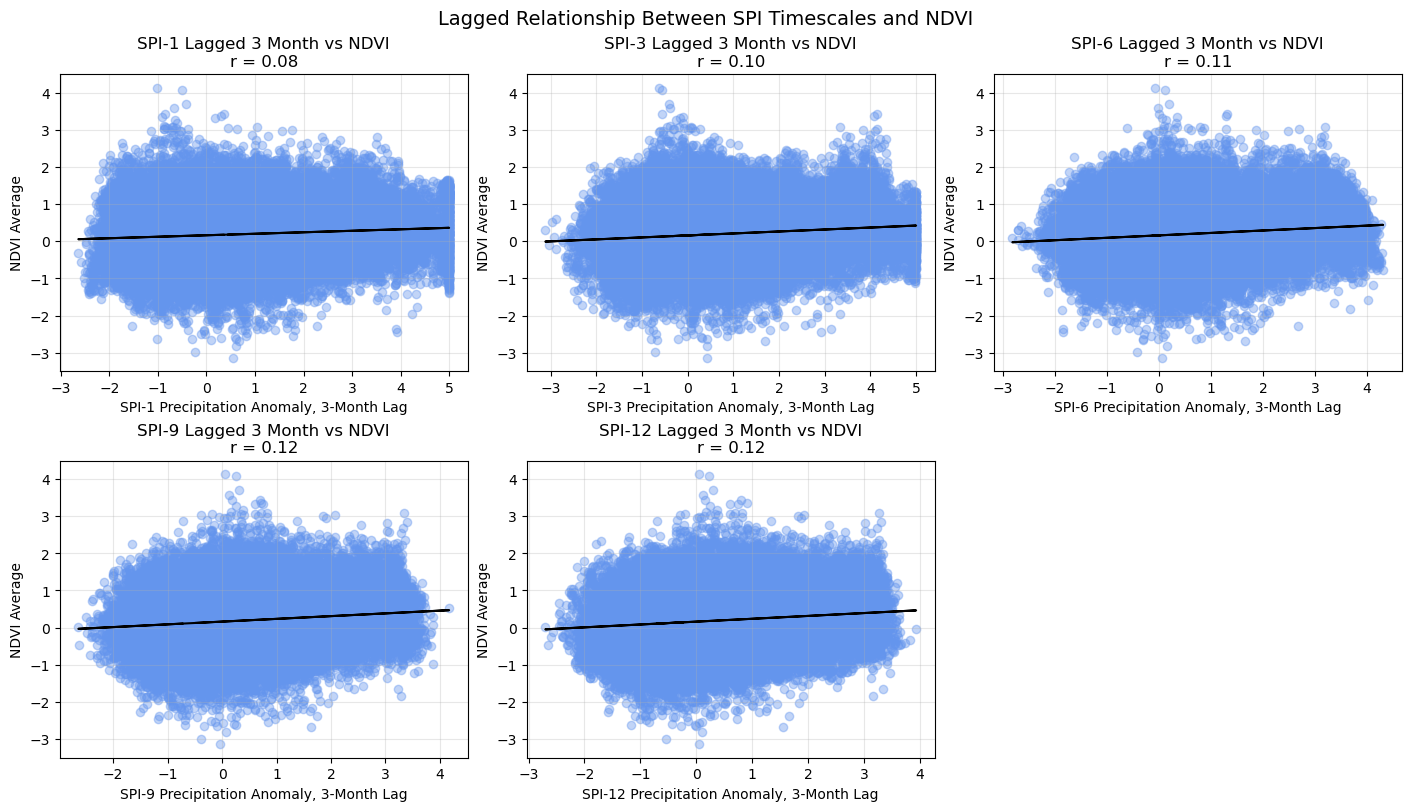

In [40]:
df['spi_1m_avg_lag3'] = df.groupby('Country')['spi_1m_avg'].shift(3)
df['spi_3m_avg_lag3'] = df.groupby('Country')['spi_3m_avg'].shift(3)
df['spi_6m_avg_lag3'] = df.groupby('Country')['spi_6m_avg'].shift(3)
df['spi_9m_avg_lag3'] = df.groupby('Country')['spi_9m_avg'].shift(3)
df['spi_12m_avg_lag3'] = df.groupby('Country')['spi_12m_avg'].shift(3)


spi_lag_cols2 = ['spi_1m_avg_lag3','spi_3m_avg_lag3','spi_6m_avg_lag3','spi_9m_avg_lag3','spi_12m_avg_lag3']

fig, axes = plt.subplots(2, 3, figsize=(14, 8), layout='constrained')

for ax, col, title in zip(axes.flat, spi_lag_cols2, titles):
    sub = df.dropna(subset=[col, 'ndvi_avg'])
    if len(sub) > 1:
        r = sub[col].corr(sub['ndvi_avg'])
        m, b = np.polyfit(sub[f'{col}'], sub['ndvi_avg'], 1)
        ax.plot(sub[f'{col}'], m*sub[f'{col}'] + b, color = 'black')
    else:
        r = np.nan
    ax.scatter(sub[col], sub['ndvi_avg'], alpha=0.4, color='cornflowerblue')
    ax.set_title(f'{title} Lagged 3 Month vs NDVI\nr = {r:.2f}')
    ax.set_xlabel(f'{title} Precipitation Anomaly, 3-Month Lag')
    ax.set_ylabel('NDVI Average')
    ax.grid(True, alpha=0.3)

plt.grid(True, alpha=0.3)
fig.delaxes(axes[1, 2])
fig.suptitle('Lagged Relationship Between SPI Timescales and NDVI', fontsize=14)
plt.show()

**Explanation:**

These scatter plots show a weak and consistent positive relationship between the NDVI avergae and 3-month lag between the SPI timescales with values ranging from (0.08-0.12). The increasing correlation values from SPI-1 to SPI-9 & 12 indicate that vegetation is more strongly influenced by medium to long-term precipitation conditions rather than short-term changes. However the response is very modest which means that there are other environmental factors impacting vegetation growth.

### Data cleaning for figure 6:

Importing datasets with longitude and latitude coordinates for Guatemala, Nicaragua, Honduras, El Salvador:

In [21]:
url1 = 'https://raw.githubusercontent.com/sarayuvanam4a38-ctrl/Vegetation-and-Precipitation-in-Central-America/refs/heads/main/gtm_admin1_boundaries.csv'
df_gtm = pd.read_csv(url1)
url2 = 'https://raw.githubusercontent.com/sarayuvanam4a38-ctrl/Vegetation-and-Precipitation-in-Central-America/refs/heads/main/nic_admin1_boundaries.csv'
df_nic = pd.read_csv(url2)
url3 = 'https://raw.githubusercontent.com/sarayuvanam4a38-ctrl/Vegetation-and-Precipitation-in-Central-America/refs/heads/main/hnd_admin1_boundaries.csv'
df_hnd = pd.read_csv(url3)
url4 = 'https://raw.githubusercontent.com/sarayuvanam4a38-ctrl/Vegetation-and-Precipitation-in-Central-America/refs/heads/main/slv_admin1_boundaries.csv'
df_slv = pd.read_csv(url4)

Removing the accents marks in the names of the departments:

In [22]:
df_hnd['adm1_name'] = (df_hnd['adm1_name'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8'))
df_gtm['adm1_name'] = (df_gtm['adm1_name'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8'))
df_nic['adm1_name'] = (df_nic['adm1_name'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8'))
df_slv['adm1_name'] = (df_slv['adm1_name'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8'))

Changing the column `admi_name` to `Department` to merge with `df`:

In [23]:
df_slv = df_slv.rename(columns={'adm1_name':'Department'})
df_gta = df_gtm.rename(columns={'adm1_name':'Department'})
df_hnd = df_hnd.rename(columns={'adm1_name':'Department'})
df_nic = df_nic.rename(columns={'adm1_name':'Department'})

Concating the dataframes to create a new one to merge with `df` and dropping unnecessary columns:

In [24]:
df_cent_amer = pd.concat([df_slv, df_gta, df_hnd, df_nic])
df_spatial = (df.reset_index().merge(df_cent_amer, on='Department',how='outer').set_index('date'))
df_spatial = df_spatial.drop(['adm0_name','adm0_name1','adm0_name2','adm0_name3','adm1_name2','adm1_name3','adm0_pcode','adm1_pcode','adm1_name1','valid_on',
                              'valid_to','area_sqkm','version','lang','lang1','lang2','lang3','adm1_ref_name'], axis=1)

### Figure 6:

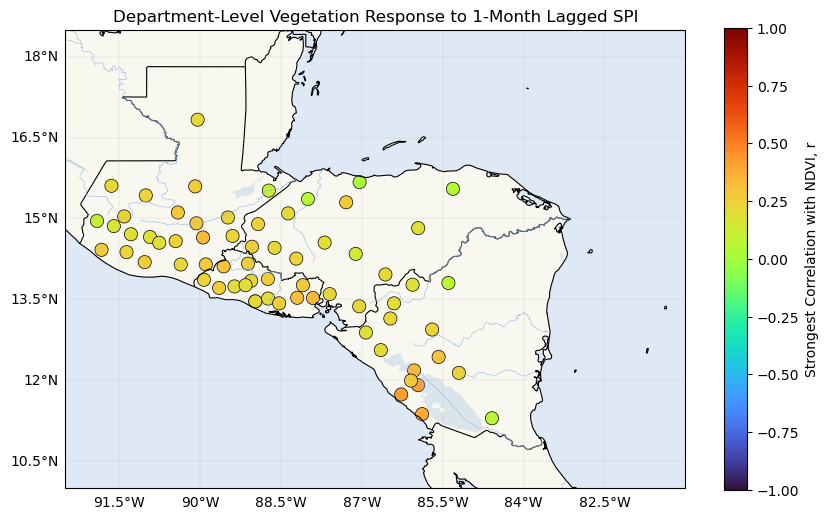

In [36]:
plot_df = df_spatial.copy()

countries = ['El Salvador', 'Guatemala', 'Honduras', 'Nicaragua']
plot_df = plot_df[plot_df['Country'].isin(countries)]

spi_cols = ['spi_1m_avg', 'spi_3m_avg', 'spi_6m_avg', 'spi_9m_avg', 'spi_12m_avg']

for spi in spi_cols:
    plot_df[f'{spi}_lag1'] = (plot_df.groupby(['Country', 'Department'])[spi].shift(1))

corr_rows = []

for (country, dept), sub in plot_df.groupby(['Country', 'Department']):
    row = {'Country': country,'Department': dept,'center_lat': sub['center_lat'].iloc[0],
           'center_lon': sub['center_lon'].iloc[0]}

    for spi in spi_cols:
        lag_col = f'{spi}_lag1'
        temp = sub[['ndvi_avg', lag_col]].dropna()

        if len(temp) >= 3:
            row[f'{spi}_r'] = temp['ndvi_avg'].corr(temp[lag_col])
        else:
            row[f'{spi}_r'] = np.nan

    corr_rows.append(row)

dept_corr = pd.DataFrame(corr_rows)

r_cols = [f'{spi}_r' for spi in spi_cols]

dept_corr['strongest_r'] = dept_corr[r_cols].max(axis=1)

dept_corr['strongest_spi'] = (dept_corr[r_cols].idxmax(axis=1).str.replace('_avg_r', '', regex=False)
                              .str.replace('spi_', 'SPI-', regex=False).str.replace('m', '', regex=False))

dept_corr = dept_corr.dropna(subset=['center_lat', 'center_lon', 'strongest_r'])

fig, ax = plt.subplots(
    figsize=(10, 8),
    subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_extent([-92.5, -81.0, 10.0, 18.5], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, alpha=0.4)
ax.add_feature(cfeature.OCEAN, alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.LAKES, alpha=0.3)
ax.add_feature(cfeature.RIVERS, linewidth=0.4)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

scatter = ax.scatter(dept_corr['center_lon'],dept_corr['center_lat'],c=dept_corr['strongest_r'],s=90,cmap='turbo',vmin=-1,
                     vmax=1,edgecolor='black',linewidth=0.5,transform=ccrs.PlateCarree())

cbar = plt.colorbar(scatter, ax=ax, shrink=0.75)
cbar.set_label('Strongest Correlation with NDVI, r')
ax.set_title('Department-Level Vegetation Response to 1-Month Lagged SPI')
plt.show()

**Explanation:**

The graph shows how the strength of the relationship between vegetation (NDVI) and precipitation (SPI) varies across departments, directly addressing how vegetation responds to precipitation anomalies. The spatial distribution reveals where the SPI-1 values lagged by 1 month has a stronger influence. Some departments display stronger precipitation–vegetation relationships while others show weaker or near-zero correlations, suggesting that regional environmental factors such as elevation, land cover, climate conditions, or soil moisture retention may influence how vegetation responds to precipitation anomalies.

### Conclusion:

The results of this study suggest that vegetation across Central American countries responds positively but relatively weakly to precipitation anomalies at different SPI timescales and lag periods. Medium-term precipitation indices, particularly SPI-3 and SPI-6, showed the clearest relationship with NDVI patterns, indicating that vegetation responds more strongly to sustained seasonal moisture conditions rather than immediate short-term rainfall or highly generalized long-term precipitation trends. The lagged analyses also showed that 1-month lag periods produced slightly stronger correlations than 3-month lag periods, suggesting that vegetation response is delayed but still most influenced by relatively recent precipitation conditions. Overall, the findings demonstrate that precipitation anomalies do influence vegetation dynamics across Central America, although vegetation response is also affected by additional environmental and climatic factors beyond precipitation.
